In [3]:
import os, sys
import numpy as np
import pickle as pk
import seaborn as sns
from random import randint
from itertools import product, chain
import scipy.interpolate as itp
from multiprocessing import Pool, Process

sys.path.append('/home/nishant/lab/MFB/scripts')
sys.path.append('/home/nishant/lab/MFB/steps')
sys.path.append('/home/nishant/lab/scripts')
from analysis import *
from peaks import *
from misc import *

# MCell analysis

In [4]:
dirType = "CaMicroDomain"
dataPath = "/media/nishant/4tb/output/MFB/" + dirType 
resultPath = "/home/nishant/lab/results/MFB/" + dirType

dirs = np.array(getDirs(dataPath, sstr=''))
for i, d in enumerate(dirs):
    print(i, d)

0 nVDCC_1_nAZ_1
1 nVDCC_1_nAZ_19
2 nVDCC_1_nAZ_29
3 nVDCC_1_nAZ_7
4 nVDCC_2_nAZ_1
5 nVDCC_2_nAZ_19
6 nVDCC_2_nAZ_29
7 nVDCC_2_nAZ_7
8 nVDCC_3_nAZ_1
9 nVDCC_3_nAZ_19
10 nVDCC_3_nAZ_29
11 nVDCC_3_nAZ_7
12 nVDCC_4_nAZ_1
13 nVDCC_4_nAZ_19
14 nVDCC_4_nAZ_29
15 nVDCC_4_nAZ_7
16 nVDCC_5_nAZ_1
17 nVDCC_5_nAZ_19
18 nVDCC_5_nAZ_29
19 nVDCC_5_nAZ_7
20 nVDCC_6_nAZ_1
21 nVDCC_6_nAZ_19
22 nVDCC_6_nAZ_29
23 nVDCC_6_nAZ_7
24 nVDCC_7_nAZ_1
25 nVDCC_7_nAZ_19
26 nVDCC_7_nAZ_29
27 nVDCC_7_nAZ_7
28 nVDCC_8_nAZ_1
29 nVDCC_8_nAZ_19
30 nVDCC_8_nAZ_29
31 nVDCC_8_nAZ_7
32 nVDCC_9_nAZ_1
33 nVDCC_9_nAZ_19
34 nVDCC_9_nAZ_29
35 nVDCC_9_nAZ_7


## Get Ca count in each box

In [5]:
def getCaCount(simdir, resultPath, timepoint=2500, step=0.05):
    """
    step: individual cell size in um
    timepoint in nano second
    """
    xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]

    ### Generate grid to store calcium ion count
    caGrid = np.zeros((int(np.ceil((ylim[1] - ylim[0])/step)), int(np.ceil((xlim[1] - xlim[0])/step))))
    #print(caGrid.shape)

    nseeds = len([a for a in os.listdir(os.path.join(dataPath, simdir))
                  if os.path.isdir(os.path.join(dataPath, simdir, a))])
    #print(nseeds)
    for seed in range(nseeds):#, desc=f'{timepoint} {simdir}'):
        data = np.genfromtxt(os.path.join(dataPath, simdir, f's_{seed+1:05}', f'viz.ascii.{timepoint:05}.dat'), 
                             usecols=(2,3,4))
        boxidx = np.array(np.floor((data - np.array([xlim[0], ylim[0], zlim[0]]))/step), dtype='int')

        for xid, yid, zid in boxidx:
            if zid == 0:
                caGrid[yid][xid] += 1

    caGrid = caGrid/nseeds
    
    if not os.path.exists(resultPath):
        os.makedirs(resultPath)

    if not os.path.exists(os.path.join(resultPath,simdir)):
        os.makedirs(os.path.join(resultPath,simdir))

    with open(os.path.join(resultPath, simdir, f'caGrid_{timepoint:05}.dat'),"wb") as outfile:
        pk.dump(caGrid, outfile)
        
    print(f'{simdir} at {timepoint} is done!')

In [ ]:
p = Pool()
for d in tqdmn(dirs):
    arg = list(product([d], [resultPath], range(0,5001,100)))
    #print(arg)
    p.starmap(getCaCount, arg)
    
p.close()

In [ ]:
for d in tqdmn(dirs[:1]):
    for t in tqdmn(range(0,5001,100), desc=d):
        #caGrid = getCaCount(d, timepoint=t)
        try:
            caGrid = getCaCount(d, resultPath, timepoint=t)
        except:
            print(f'ERROR in {d} at {t}')

## Plot and save caGrid

In [ ]:
for d in tqdmn(dirs[9:13]):
    try:
        xlim, ylim, zlim = [-2.05, 2.05], [-1.25, 1.25], [-0.4, 0.4]
        maxCa = 0
        for t in range(0,5001,100):
            with open(os.path.join(resultPath, d, f'caGrid_{t:05}.dat'), "rb") as infile:
                caGrid = pk.load(infile)
            caGrid *= 0.83 # conversion from number of Ca ions to conc. in uM
            curCaMax = np.max(caGrid)
            if curCaMax > maxCa:
                maxCa = curCaMax

        for t in tqdmn(range(0,5001,100), desc=d):
            with open(os.path.join(resultPath, d, f'caGrid_{t:05}.dat'), "rb") as infile:
                caGrid = pk.load(infile)
            caGrid *= 13.28 # conversion from number of Ca ions to conc. in uM (vol = (50nm)^3)

            ### Plot the heatmap of the calcium
            plt.subplots(figsize=(8,4))
            ax = sns.heatmap(caGrid, vmax=maxCa, vmin=0, xticklabels=xlim, yticklabels=ylim)
            ax.text(2, 2, f'{t/1000} ms', c='w', size=25)
            ax.set_xticks(range(0,100,caGrid.shape[1]))
            ax.set_yticks(range(0,100,caGrid.shape[0]))
            ax.invert_yaxis()
            plt.savefig(os.path.join(resultPath, d, f'caGrid_{t:05}.png'), dpi=200, bbox_inches='tight', pad_inches=0.0, transparent=True)
            
    except:
        print(f'ERROR in {d}')

## Generate radial plot for single VDCC cluster sims

In [445]:
def getRadialCaDist(simdir, timepoint=2500, step=50, dist=1000):
    """
    step: bin size in nm
    timepoint in nano second
    """
    nseeds = len([a for a in os.listdir(os.path.join(dataPath, simdir)) if os.path.isdir(os.path.join(dataPath, simdir, a))])    
    #nseeds=30
    
    bins=np.arange(0,(dist+1)/1000,step/1000)
    caConc = np.zeros((nseeds, len(bins)-1))

    for seed in range(nseeds):
        data = np.genfromtxt(os.path.join(dataPath, simdir, f's_{seed+1:05}', f'viz.ascii.{timepoint:05}.dat'), usecols=(2,3))
        rd = np.sqrt(np.sum(data**2, axis=1))

        num = np.zeros(len(bins)-1, dtype='int')
        for d in rd:
            id = int(np.floor(d*1000/step))
            try:
                caConc[seed][id] += 1
            except IndexError:
                continue

        for i,n in enumerate(caConc[seed]):
            caConc[seed][i] = 660.6*n/(2*i+1)/step**2

    sdCaConc = np.std(caConc, axis=0)
    caConc = np.mean(caConc, axis=0)

    return caConc, sdCaConc, bins

In [459]:
for i in tqdmn(range(1,10)):
    timepoint = 2400
    caConc, sdCaConc, bins = getRadialCaDist(f'nVDCC_{i}_nAZ_1', timepoint=timepoint, step=50)
    np.savetxt(os.path.join(resultPath, f'nVDCC_{i}_nAZ_1', f'caConc_nVDCC_{i}_{timepoint:05}.dat'),
               np.array([bins[:-1], caConc, sdCaConc]).T, fmt='%.5f', header='bins\tcaConc\tstd')

## Gerenerate individual Ca distribution plot

In [ ]:
for i in tqdmn(range(1,10)):
    timepoint = 2400
    bins, caConc, sdCaConc = np.genfromtxt(os.path.join(resultPath, f'nVDCC_{i}_nAZ_1', f'caConc_nVDCC_{i}_{timepoint:05}.dat')).T
    
    f, ax = plt.subplots(1, figsize=(6,4))
    ax.plot(bins, caConc, label=str(i))
    ax.fill_between(bins, caConc-sdCaConc, caConc+sdCaConc, alpha=0.1)

    #plt.savefig(os.path.join(resultPath, f'nVDCC_{i}_nAZ_1', f'caConc_nVDCC_{i}_{timepoint:05}.png'), dpi=300, bbox_inches='tight', pad_inches=0.0, transparent=True)

## Generate a compiled Ca distribution plot

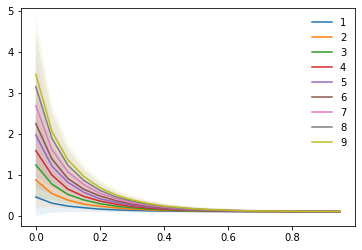

In [464]:
f, ax = plt.subplots(1, figsize=(6,4))

for i in tqdmn(range(1,10)):
    timepoint = 2400
    bins, caConc, sdCaConc = np.genfromtxt(os.path.join(resultPath, f'nVDCC_{i}_nAZ_1', f'caConc_nVDCC_{i}_{timepoint:05}.dat')).T
    
    ax.plot(bins, caConc, label=str(i))
    ax.fill_between(bins, caConc-sdCaConc, caConc+sdCaConc, alpha=0.1)
    ax.legend(frameon=False)

plt.savefig(os.path.join(resultPath, f'caConc_nVDCC_{timepoint:05}_std.png'), dpi=300, bbox_inches='tight', pad_inches=0.0, transparent=True)

## compiled normed Ca distribution plot 

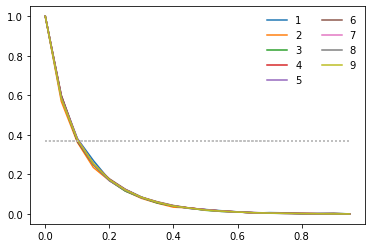

In [473]:
f, ax = plt.subplots(1, figsize=(6,4))

for i in tqdmn(range(1,10)):
    timepoint = 2400
    bins, caConc, sdCaConc = np.genfromtxt(os.path.join(resultPath, f'nVDCC_{i}_nAZ_1', f'caConc_nVDCC_{i}_{timepoint:05}.dat')).T
    caConc = (caConc - min(caConc))/max(caConc - min(caConc))
    
    ax.plot(bins, caConc, label=str(i))
    ax.plot(bins, [0.3678]*len(bins), linestyle=':', c='silver')
    #ax.fill_between(bins, caConc-sdCaConc, caConc+sdCaConc, alpha=0.1)
    ax.legend(frameon=False, ncol=2)

plt.savefig(os.path.join(resultPath, f'caConc_nVDCC_{timepoint:05}_normed.png'), dpi=300, bbox_inches='tight', pad_inches=0.0, transparent=True)